# Cinemath ML Notebook
### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Step 1 — Data Cleaning & Pre-processing

In [2]:
# Load and combine all 8 CSV files
files = [f'../geoff run/output_{i}.csv' for i in range(1, 9)]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(f"Combined shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Combined shape: (10669089, 10)
Columns: ['username', 'tmdb_id', 'movie_title', 'rating', 'genre', 'subgenre_1', 'subgenre_2', 'subgenre_3', 'subgenre_4', 'subgenre_5']


In [3]:
# Drop rows where target is missing
df = df.dropna(subset=['rating'])

# Drop rows with no genre signal
df = df.dropna(subset=['tmdb_id'])

# Remove duplicate (user, movie) pairs
df = df.drop_duplicates(subset=['username', 'movie_title'])

# Drop non-feature columns
df = df.drop(columns=['tmdb_id', 'movie_title'])

# Fill missing genre slots
genre_cols = ['genre', 'subgenre_1', 'subgenre_2', 'subgenre_3', 'subgenre_4', 'subgenre_5']
df[genre_cols] = df[genre_cols].fillna('Unknown')

In [4]:
# Sample 20% of users before feature engineering to manage memory
all_users = df['username'].unique()
np.random.seed(42)
sampled_users = np.random.choice(all_users, size=int(len(all_users) * 0.20), replace=False)
df = df[df['username'].isin(sampled_users)]

print(f"Rows after sampling: {len(df)}")
print(f"Users after sampling: {df['username'].nunique()}")

Rows after sampling: 1637859
Users after sampling: 761


In [5]:
# User-level aggregates — computed before encoding
user_stats = df.groupby('username')['rating'].agg(
    user_avg_rating='mean',
    user_rating_std='std',
    user_rating_count='count'
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)

df = df.merge(user_stats, on='username', how='left')

# Encode username as numeric ID then drop
df['user_id'] = pd.factorize(df['username'])[0]
df = df.drop(columns=['username'])

# One-hot encode genres
df = pd.get_dummies(df, columns=genre_cols)

In [6]:
# User-aware train/test split — prevents data leakage
users = df['user_id'].unique()
np.random.seed(42)
np.random.shuffle(users)

split_idx   = int(len(users) * 0.75)
train_users = users[:split_idx]
test_users  = users[split_idx:]

train_df = df[df['user_id'].isin(train_users)]
test_df  = df[df['user_id'].isin(test_users)]

X_train = train_df.drop(columns=['rating'])
y_train = train_df['rating']
X_test  = test_df.drop(columns=['rating'])
y_test  = test_df['rating']

# Confirm zero overlap
assert len(set(train_users) & set(test_users)) == 0, 'User leakage detected!'

In [7]:
# Scaling — for linear models and KNN only, NOT tree-based
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [8]:
# Evaluation helper — used by every model
def evaluate(name, y_train, y_train_pred, y_test, y_test_pred):
    train_r2  = r2_score(y_train, y_train_pred)
    test_r2   = r2_score(y_test,  y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    print(f'{name}')
    print(f'  Train R²  : {train_r2:.4f}')
    print(f'  Test  R²  : {test_r2:.4f}')
    print(f'  Test  RMSE: {test_rmse:.4f}\n')

# Step 2 — Baseline: Linear Regression (OLS)

In [9]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

evaluate(
    'Linear Regression (OLS)',
    y_train, lr.predict(X_train_scaled),
    y_test,  lr.predict(X_test_scaled)
)

Linear Regression (OLS)
  Train R²  : 0.1532
  Test  R²  : 0.1578
  Test  RMSE: 0.9581



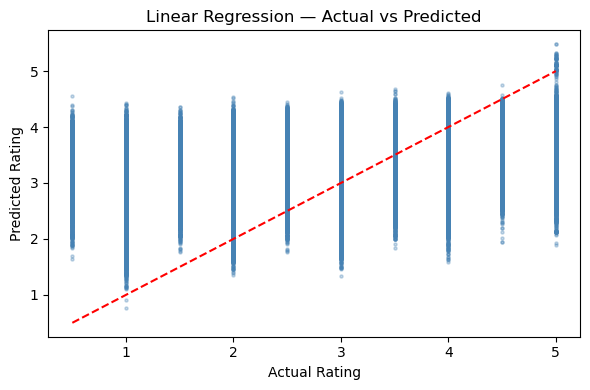

In [10]:
# Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, lr.predict(X_test_scaled), alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

# Step 3 — Regularized Linear Models

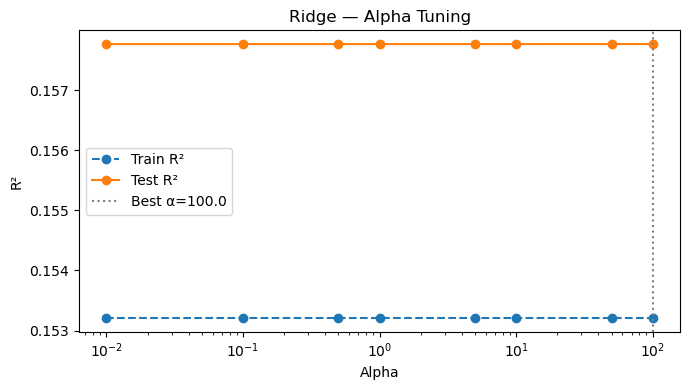

In [11]:
# Ridge — tune alpha
ridge_train_r2, ridge_test_r2 = [], []
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

for a in alphas:
    m = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_train_r2.append(r2_score(y_train, m.predict(X_train_scaled)))
    ridge_test_r2.append(r2_score(y_test,  m.predict(X_test_scaled)))

best_alpha_ridge = alphas[np.argmax(ridge_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, ridge_train_r2, 'o--', label='Train R²')
plt.plot(alphas, ridge_test_r2,  'o-',  label='Test R²')
plt.xscale('log')
plt.axvline(best_alpha_ridge, color='gray', linestyle=':', label=f'Best α={best_alpha_ridge}')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Ridge — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
ridge = Ridge(alpha=best_alpha_ridge).fit(X_train_scaled, y_train)

evaluate(
    f'Ridge Regression (α={best_alpha_ridge})',
    y_train, ridge.predict(X_train_scaled),
    y_test,  ridge.predict(X_test_scaled)
)

Ridge Regression (α=100.0)
  Train R²  : 0.1532
  Test  R²  : 0.1578
  Test  RMSE: 0.9581



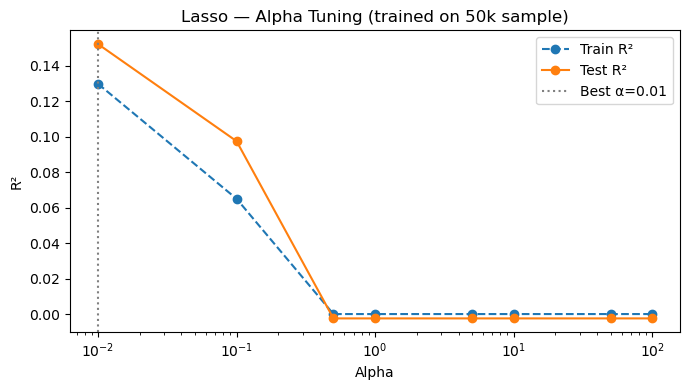

In [ ]:
# Lasso — sampled due to memory constraints
X_train_lasso = X_train_scaled[:50000]
y_train_lasso = y_train.iloc[:50000]

lasso_train_r2, lasso_test_r2 = [], []

for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_lasso, y_train_lasso)
    lasso_train_r2.append(r2_score(y_train_lasso, m.predict(X_train_lasso)))
    lasso_test_r2.append(r2_score(y_test, m.predict(X_test_scaled)))

best_alpha_lasso = alphas[np.argmax(lasso_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, lasso_train_r2, 'o--', label='Train R²')
plt.plot(alphas, lasso_test_r2,  'o-',  label='Test R²')
plt.xscale('log')
plt.axvline(best_alpha_lasso, color='gray', linestyle=':', label=f'Best α={best_alpha_lasso}')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Lasso — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train_lasso, y_train_lasso)

evaluate(
    f'Lasso Regression (α={best_alpha_lasso})',
    y_train_lasso, lasso.predict(X_train_lasso),
    y_test,        lasso.predict(X_test_scaled)
)S

Lasso Regression (α=0.01, sample=50k)
  Train R²  : 0.1297
  Test  R²  : 0.1521
  Test  RMSE: 0.9614



# Step 4 — KNN Regression

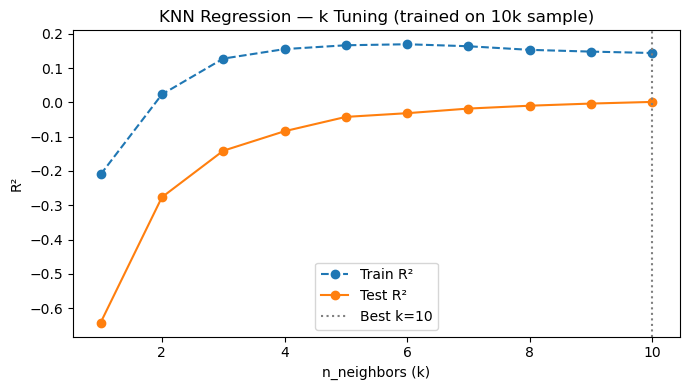

In [15]:
# KNN — small sample due to computational constraints
X_train_knn = X_train_scaled[:10000]
y_train_knn = y_train.iloc[:10000]

knn_train_r2, knn_test_r2 = [], []
k_range = range(1, 11)

for k in k_range:
    m = KNeighborsRegressor(n_neighbors=k, n_jobs=-1).fit(X_train_knn, y_train_knn)
    knn_train_r2.append(r2_score(y_train_knn, m.predict(X_train_knn)))
    knn_test_r2.append(r2_score(y_test, m.predict(X_test_scaled)))

best_k = list(k_range)[np.argmax(knn_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(k_range, knn_train_r2, 'o--', label='Train R²')
plt.plot(k_range, knn_test_r2,  'o-',  label='Test R²')
plt.axvline(best_k, color='gray', linestyle=':', label=f'Best k={best_k}')
plt.xlabel('n_neighbors (k)')
plt.ylabel('R²')
plt.title('KNN Regression — k Tuning (trained on 10k sample)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
knn = KNeighborsRegressor(n_neighbors=best_k).fit(X_train_knn, y_train_knn)

evaluate(
    f'KNN Regression (k={best_k}, sample=50k)',
    y_train_knn, knn.predict(X_train_knn),
    y_test,      knn.predict(X_test_scaled)
)

KNN Regression (k=10, sample=50k)
  Train R²  : 0.1440
  Test  R²  : 0.0014
  Test  RMSE: 1.0433



# Step 5 — Decision Tree

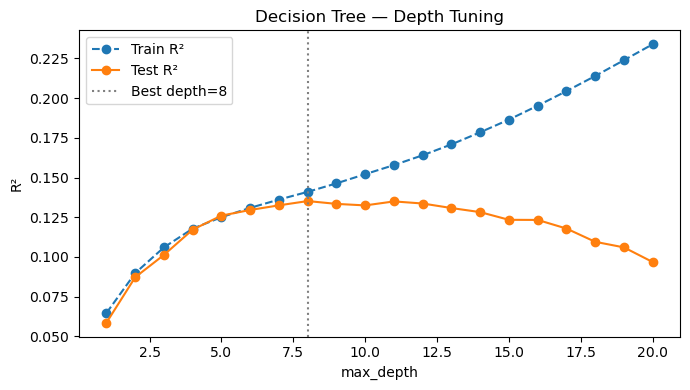

In [17]:
# Decision Tree — tune max_depth
dt_train_r2, dt_test_r2 = [], []
depth_range = range(1, 21)

for d in depth_range:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    dt_train_r2.append(r2_score(y_train, m.predict(X_train)))
    dt_test_r2.append(r2_score(y_test,  m.predict(X_test)))

best_depth = depth_range.start + np.argmax(dt_test_r2)

plt.figure(figsize=(7, 4))
plt.plot(depth_range, dt_train_r2, 'o--', label='Train R²')
plt.plot(depth_range, dt_test_r2,  'o-',  label='Test R²')
plt.axvline(best_depth, color='gray', linestyle=':', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Decision Tree — Depth Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42).fit(X_train, y_train)

evaluate(
    f'Decision Tree (max_depth={best_depth})',
    y_train, dt.predict(X_train),
    y_test,  dt.predict(X_test)
)

Decision Tree (max_depth=8)
  Train R²  : 0.1410
  Test  R²  : 0.1352
  Test  RMSE: 0.9709



# Step 6 — Random Forest

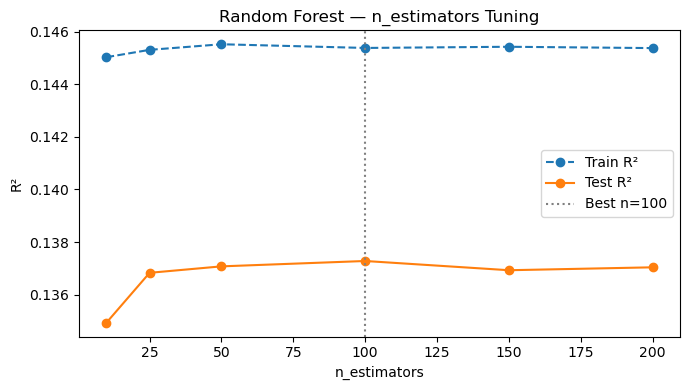

In [19]:
# Random Forest — tune n_estimators
rf_train_r2, rf_test_r2 = [], []
estimator_range = [10, 25, 50, 100, 150, 200]

for n in estimator_range:
    m = RandomForestRegressor(n_estimators=n, max_depth=best_depth, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    rf_train_r2.append(r2_score(y_train, m.predict(X_train)))
    rf_test_r2.append(r2_score(y_test,  m.predict(X_test)))

best_n_estimators = estimator_range[np.argmax(rf_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(estimator_range, rf_train_r2, 'o--', label='Train R²')
plt.plot(estimator_range, rf_test_r2,  'o-',  label='Test R²')
plt.axvline(best_n_estimators, color='gray', linestyle=':', label=f'Best n={best_n_estimators}')
plt.xlabel('n_estimators')
plt.ylabel('R²')
plt.title('Random Forest — n_estimators Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest (n=100, depth=8)
  Train R²  : 0.1454
  Test  R²  : 0.1373
  Test  RMSE: 0.9697



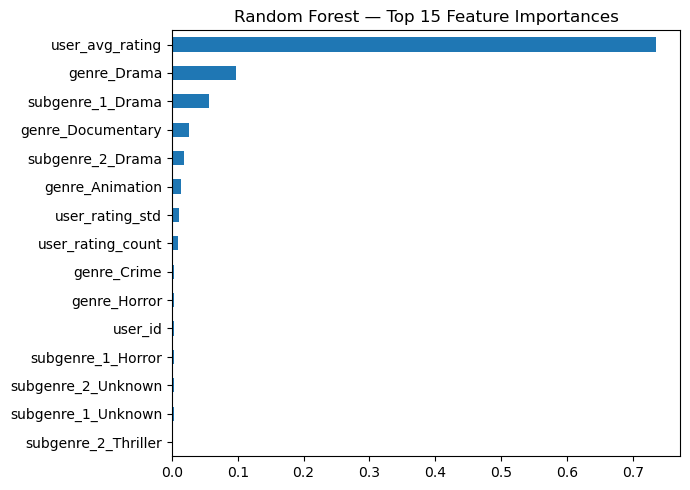

In [20]:
rf = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_depth,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

evaluate(
    f'Random Forest (n={best_n_estimators}, depth={best_depth})',
    y_train, rf.predict(X_train),
    y_test,  rf.predict(X_test)
)

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Random Forest — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 7 — Gradient Boosting

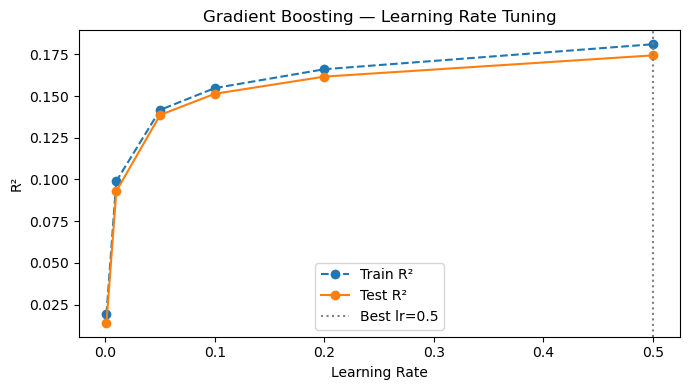

In [21]:
# Gradient Boosting — tune learning_rate with fixed n_estimators
gb_train_r2, gb_test_r2 = [], []
lr_range = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]

for lr_val in lr_range:
    m = GradientBoostingRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=lr_val, random_state=42
    ).fit(X_train, y_train)
    gb_train_r2.append(r2_score(y_train, m.predict(X_train)))
    gb_test_r2.append(r2_score(y_test,  m.predict(X_test)))

best_lr = lr_range[np.argmax(gb_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(lr_range, gb_train_r2, 'o--', label='Train R²')
plt.plot(lr_range, gb_test_r2,  'o-',  label='Test R²')
plt.axvline(best_lr, color='gray', linestyle=':', label=f'Best lr={best_lr}')
plt.xlabel('Learningz Rate')
plt.ylabel('R²')
plt.title('Gradient Boosting — Learning Rate Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Gradient Boosting (lr=0.5, n=100, depth=3)
  Train R²  : 0.1811
  Test  R²  : 0.1744
  Test  RMSE: 0.9486



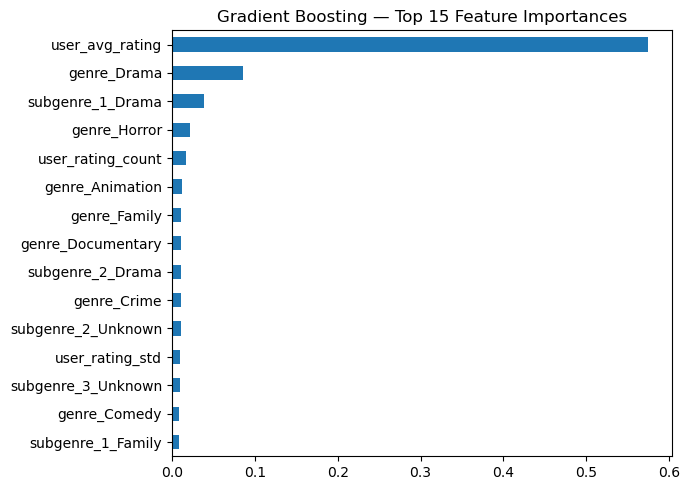

In [22]:
gb = GradientBoostingRegressor(
    n_estimators=100, max_depth=3,
    learning_rate=best_lr, random_state=42
).fit(X_train, y_train)

evaluate(
    f'Gradient Boosting (lr={best_lr}, n=100, depth=3)',
    y_train, gb.predict(X_train),
    y_test,  gb.predict(X_test)
)

# Feature importance
feat_imp_gb = pd.Series(gb.feature_importances_, index=X_train.columns)
feat_imp_gb.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Gradient Boosting — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 8 — Model Comparison

In [23]:
models = {
    'Linear Regression':  (lr,    X_test_scaled),
    'Ridge':              (ridge, X_test_scaled),
    'Lasso':              (lasso, X_test_scaled),
    'KNN':                (knn,   X_test_scaled),
    'Decision Tree':      (dt,    X_test),
    'Random Forest':      (rf,    X_test),
    'Gradient Boosting':  (gb,    X_test),
}

results = []
for name, (model, X_eval) in models.items():
    preds = model.predict(X_eval)
    results.append({
        'Model': name,
        'Test R²':   round(r2_score(y_test, preds), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    })

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False).reset_index(drop=True)
results_df

,Model,Test R²,Test RMSE
0,Gradient Boosting,0.1744,0.9486
1,Linear Regression,0.1578,0.9581
2,Ridge,0.1578,0.9581
3,Lasso,0.1521,0.9614
4,Random Forest,0.1373,0.9697
5,Decision Tree,0.1352,0.9709
6,KNN,0.0014,1.0433


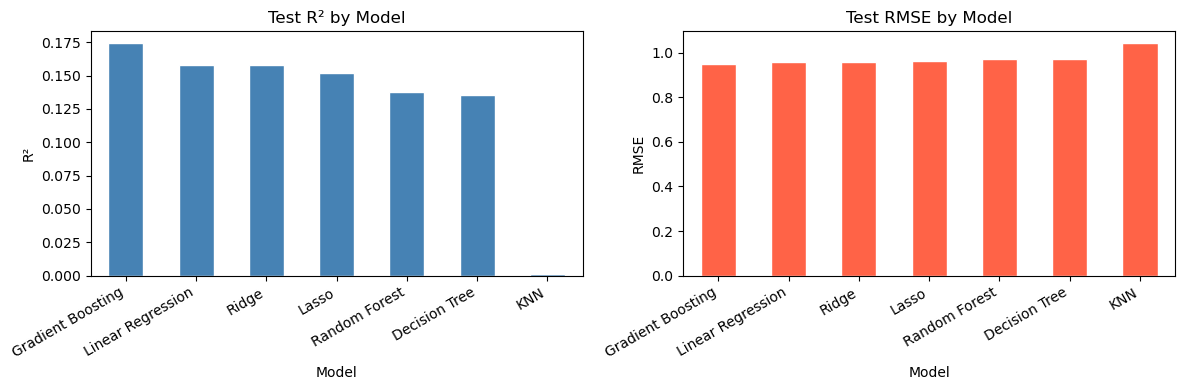

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df.plot(
    x='Model', y='Test R²', kind='bar',
    ax=axes[0], legend=False, color='steelblue', edgecolor='white'
)
axes[0].set_title('Test R² by Model')
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[0].set_ylabel('R²')

results_df.plot(
    x='Model', y='Test RMSE', kind='bar',
    ax=axes[1], legend=False, color='tomato', edgecolor='white'
)
axes[1].set_title('Test RMSE by Model')
axes[1].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()